# Train a Small Model from Scratch

This notebook trains a deliberately small dMRI inference model in a few minutes on CPU. It uses the same simulator, model, and loss implementations as a full training run, but leaves out streaming data, checkpointing, WandB, and Hydra orchestration.

Every update receives a newly simulated batch, while a separate fixed batch measures held-out performance. The 25,000 updates process 1.6 million simulations in about one to two minutes on a modern CPU. The resulting model is still much smaller than a scientific checkpoint; see the [training guide](../guides/training.md) when you are ready for a full run.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx
from omegaconf import OmegaConf

from dmri.nn.autoregressive import DMRIModelSelectionAmortizedPriorConfig
from dmri.nn.dmri_reconstruction_model import (
    DMRIInferenceModel,
    DMRIInferenceModelConfigMaskPriorAmortizedPP,
)
from dmri.nn.embedding_net import DMRIEmbeddingConfig
from dmri.nn.simformer import DMRIThetaInferenceConfig
from dmri.train.build_simulator import build_simulator

print(jax.devices())

[CudaDevice(id=0)]


## 1. Build a small simulator

`BallStick` has only two possible signal compartments. Using 16 measurements keeps both simulation and attention inexpensive.

In [2]:
simulator_cfg = OmegaConf.create({
    "simulator": {
        "model_class": "dmri.simulators.models.BallStick",
        "posterior_score": False,
        "mask_prior": {"alpha": 1.0, "beta": 1.0},
        "acquisitions": [
            {
                "_target_": "dmri.simulators.random_clinical_acquisition",
                "_partial_": True,
                "num_acquisitions": 16,
            }
        ],
    }
})
sim_type, (simulator,) = build_simulator(simulator_cfg)
simulate_batch = jax.jit(jax.vmap(simulator))

batch_size = 64
validation_size = 256
validation_batch = simulate_batch(jax.random.split(jax.random.key(0), validation_size))
print({name: value.shape for name, value in validation_batch.items() if name != "acq"})

{'mask_prior': (256, 1), 'model_mask': (256, 2), 'theta': (256, 5), 'x': (256, 16)}


## 2. Build a tiny model

Production configurations use wider, deeper networks. Here every transformer has one layer and one attention head, giving a model small enough for an interactive example.

In [3]:
model_cfg = DMRIInferenceModelConfigMaskPriorAmortizedPP(
    simulator=sim_type,
    model_dim=16,
    embedding_cfg=DMRIEmbeddingConfig(
        num_layers=1, num_heads=1, widening_factor=2, attn_size=16
    ),
    model_selection_cfg=DMRIModelSelectionAmortizedPriorConfig(
        num_layers=1,
        num_heads=1,
        widening_factor=2,
        attn_size=16,
        prior_params_embed_dim=16,
    ),
    theta_inference_cfg=DMRIThetaInferenceConfig(
        num_layers=1,
        num_heads=1,
        widening_factor=2,
        attn_size=16,
        time_embed_dim=16,
    ),
)
model = DMRIInferenceModel(model_cfg, nnx.Rngs(0))
graphdef, params, model_state = nnx.split(model, nnx.Param, ...)

num_parameters = sum(x.size for x in jax.tree.leaves(params))
print(f"parameters: {num_parameters:,}")

parameters: 17,512


## 3. Train on fresh simulations

The model returns a model-selection loss and a parameter-inference loss. Each update below uses 64 newly simulated examples. The first update includes JAX compilation and is therefore much slower than the remaining updates.

initial validation loss: 6.958


step    1: total=7.436, mask=5.915, theta=1.521


step 2500: total=1.633, mask=0.322, theta=1.310


step 5000: total=1.422, mask=0.341, theta=1.081


step 7500: total=1.564, mask=0.327, theta=1.237


...

step 20000: total=1.262, mask=0.116, theta=1.146


step 22500: total=1.263, mask=0.196, theta=1.067


step 25000: total=1.772, mask=0.210, theta=1.562


final validation loss:   1.500
elapsed: 173.6 seconds (6.9 ms/update)


E0802 21:30:11.509185  387669 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


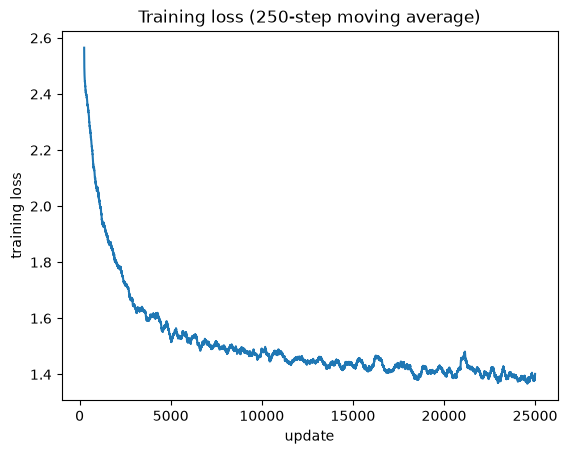

In [4]:
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)


@jax.jit
def update(params, model_state, opt_state, batch, rng):
    def loss_fn(params):
        train_model = nnx.merge(graphdef, params, model_state, copy=True)
        train_model.train()
        losses = train_model.loss_fn(rng, **batch, use_loss_mask=True)
        _, _, next_model_state = nnx.split(train_model, nnx.Param, ...)
        return losses.sum(), (losses, next_model_state)

    (loss, (losses, next_model_state)), grads = jax.value_and_grad(
        loss_fn, has_aux=True
    )(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, next_model_state, opt_state, loss, losses


@jax.jit
def evaluate(params, model_state, batch, rng):
    eval_model = nnx.merge(graphdef, params, model_state, copy=True)
    eval_model.eval()
    return eval_model.loss_fn(rng, **batch, use_loss_mask=True)


evaluation_rng = jax.random.key(2)
initial_validation_losses = evaluate(
    params, model_state, validation_batch, evaluation_rng
)
print(f"initial validation loss: {initial_validation_losses.sum():.3f}")

num_steps = 25_000
history = []
rng = jax.random.key(1)
started = time.perf_counter()
for step in range(num_steps):
    rng, simulation_rng, step_rng = jax.random.split(rng, 3)
    train_batch = simulate_batch(jax.random.split(simulation_rng, batch_size))
    params, model_state, opt_state, loss, losses = update(
        params, model_state, opt_state, train_batch, step_rng
    )
    history.append(loss)
    if step == 0 or (step + 1) % 2_500 == 0:
        print(
            f"step {step + 1:4d}: total={loss:.3f}, "
            f"mask={losses[0]:.3f}, theta={losses[1]:.3f}"
        )

history = jnp.asarray(history)
history.block_until_ready()
elapsed = time.perf_counter() - started
final_validation_losses = evaluate(
    params, model_state, validation_batch, evaluation_rng
)
print(f"final validation loss:   {final_validation_losses.sum():.3f}")
print(f"elapsed: {elapsed:.1f} seconds ({1_000 * elapsed / num_steps:.1f} ms/update)")

window = 250
smoothed_history = jnp.convolve(history, jnp.ones(window) / window, mode="valid")
plt.plot(jnp.arange(window, num_steps + 1), smoothed_history)
plt.xlabel("update")
plt.ylabel("training loss")
plt.title(f"Training loss ({window}-step moving average)")
plt.show()

## 4. Evaluate held-out model selection

Reassemble the trained model and compare sampled masks with targets that were not used for optimization. This is a small synthetic validation set, but unlike training-batch accuracy it measures whether the model learned beyond individual examples.

In [5]:
trained_model = nnx.merge(graphdef, params, model_state, copy=True)
trained_model.eval()
predicted_masks = jax.vmap(trained_model.sample_mask, in_axes=(0, 0, 0, 0))(
    jax.random.split(jax.random.key(3), validation_size),
    validation_batch["acq"],
    validation_batch["x"],
    validation_batch["mask_prior"],
)

matches = predicted_masks == validation_batch["model_mask"]
print(f"component accuracy: {matches.mean():.3f}")
print(f"exact-mask accuracy: {matches.all(axis=-1).mean():.3f}")
print("first eight targets and predictions:")
print(jnp.c_[validation_batch["model_mask"][:8], predicted_masks[:8]].astype(int))

component accuracy: 0.918
exact-mask accuracy: 0.836
first eight targets and predictions:


[[1 0 1 0]
 [1 1 1 1]
 [1 1 1 1]
 [1 0 1 0]
 [1 0 1 0]
 [1 0 1 0]
 [0 1 1 1]
 [0 1 0 1]]


## 5. Sample the parameter posterior

Choose a held-out example containing both compartments and draw parameter samples conditioned on its ground-truth mask. The dashed lines show the standardized parameters used to generate the observation. With this short training run, the marginals are only a qualitative check that the learned posterior covers plausible values.

mask: [1 1]
posterior-mean RMSE: 0.529


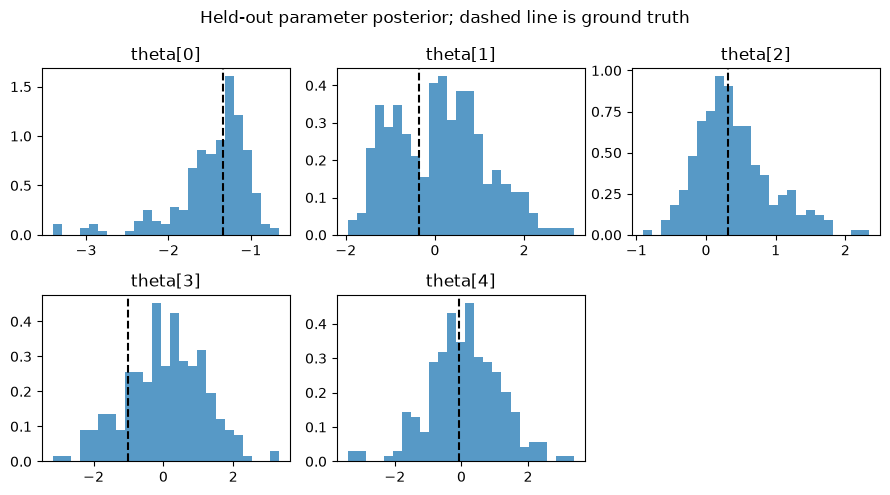

In [6]:
sample_index = int(jnp.argmax(validation_batch["model_mask"].sum(axis=-1)))
acq = jax.tree.map(lambda value: value[sample_index], validation_batch["acq"])
x = validation_batch["x"][sample_index]
true_mask = validation_batch["model_mask"][sample_index]
true_theta = validation_batch["theta"][sample_index]

num_theta_samples = 256
theta_samples = jax.vmap(
    lambda key: trained_model.sample_theta(key, acq, x, true_mask, num_steps=32)
)(jax.random.split(jax.random.key(4), num_theta_samples))

posterior_mean = theta_samples.mean(axis=0)
print("mask:", true_mask.astype(int))
print(
    f"posterior-mean RMSE: {jnp.sqrt(jnp.mean((posterior_mean - true_theta) ** 2)):.3f}"
)

theta_dim = theta_samples.shape[-1]
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
for index, ax in enumerate(axes.flat):
    if index >= theta_dim:
        ax.axis("off")
        continue
    ax.hist(theta_samples[:, index], bins=25, density=True, alpha=0.75)
    ax.axvline(true_theta[index], color="black", linestyle="--")
    ax.set_title(f"theta[{index}]")
fig.suptitle("Held-out parameter posterior; dashed line is ground truth")
fig.tight_layout()
plt.show()

## From notebook to full training

This is real online training, but it is intentionally small. For useful inference, use the Hydra training CLI described in the [training guide](../guides/training.md). Full runs use larger model families, networks, and batches; maintain EMA parameters; evaluate more thoroughly; and save reproducible checkpoints.